# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ruptures import Binseg
from pandas.plotting import autocorrelation_plot

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

In [3]:
categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-03-01,43.30,43.37,43.10,43.22,3245500,"(41.308, 43.335]","(41.547000000000004, 43.581]","(41.188, 43.207]","(41.477000000000004, 43.508]","(3023300.85, 3295666.8]"
1,2005-03-08,43.71,44.08,43.59,44.03,2674900,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]"
2,2005-03-09,43.95,44.20,43.92,44.02,3025000,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(3023300.85, 3295666.8]"
3,2005-03-11,44.31,44.67,44.28,44.43,2659600,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]"
4,2005-03-16,44.29,44.35,44.20,44.31,2223300,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2184413.7229999998, 2478568.95]"


# Time series analysis

formatting date

In [4]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
# categorized_df

0    2005-03-01
1    2005-03-08
2    2005-03-09
3    2005-03-11
4    2005-03-16
5    2005-03-21
6    2005-03-22
7    2005-03-23
8    2005-04-01
9    2005-04-07
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2881 entries, 0 to 2880
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2881 non-null   datetime64[ns]
 1   Open             2881 non-null   float64       
 2   High             2881 non-null   float64       
 3   Low              2881 non-null   float64       
 4   Close            2881 non-null   float64       
 5   Volume           2881 non-null   int64         
 6   Open_category    2881 non-null   object        
 7   High_category    2881 non-null   object        
 8   Low_ca

#### Trend Analysis

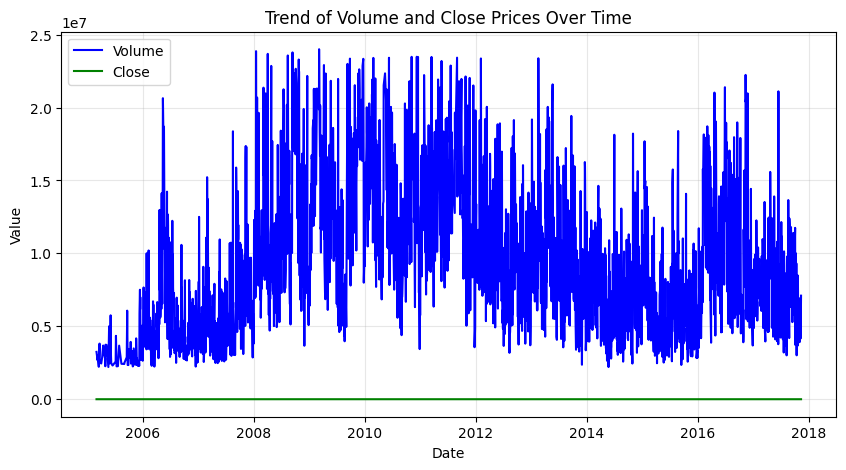

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Volume', color='blue')
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close', color='green')
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Trend of Volume and Close Prices Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Seasonality Analysis

In [6]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month
0,2005-03-01,43.30,43.37,43.100,43.22,3245500,"(41.308, 43.335]","(41.547000000000004, 43.581]","(41.188, 43.207]","(41.477000000000004, 43.508]","(3023300.85, 3295666.8]",2005,3
1,2005-03-08,43.71,44.08,43.590,44.03,2674900,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]",2005,3
2,2005-03-09,43.95,44.20,43.920,44.02,3025000,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(3023300.85, 3295666.8]",2005,3
3,2005-03-11,44.31,44.67,44.280,44.43,2659600,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2478568.95, 2750934.9]",2005,3
4,2005-03-16,44.29,44.35,44.200,44.31,2223300,"(43.335, 45.22]","(43.581, 45.472]","(43.207, 45.084]","(43.508, 45.397]","(2184413.7229999998, 2478568.95]",2005,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2876,2017-11-06,120.72,121.85,120.680,121.65,6952387,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(6836424.15, 7108790.1]",2017,11
2877,2017-11-07,121.15,121.31,120.930,121.21,4164336,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(4112764.65, 4385130.6]",2017,11
2878,2017-11-08,121.95,122.25,121.590,121.63,5564212,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(5474594.4, 5746960.35]",2017,11
2879,2017-11-09,121.85,122.41,121.730,122.13,6072394,"(120.617, 122.502]","(121.109, 123.0]","(120.161, 122.038]","(120.927, 122.815]","(6019326.3, 6291692.25]",2017,11


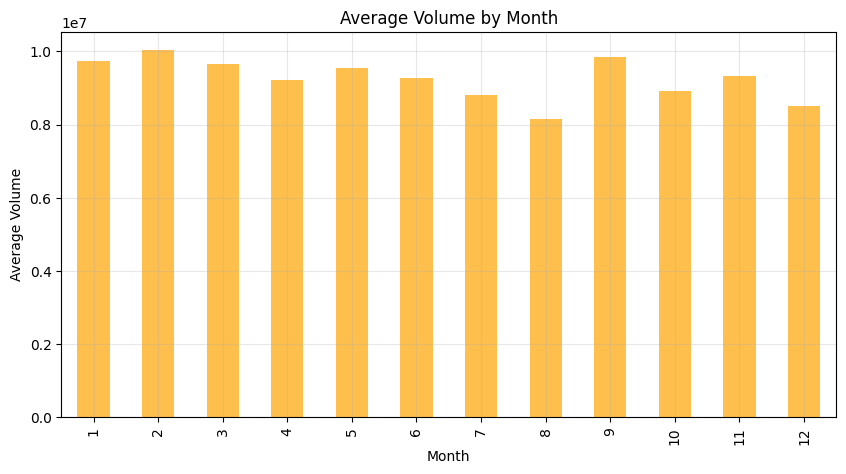

In [7]:
# Calculate the average trading volume for each month
monthly_avg_volume = categorized_df.groupby('Month')['Volume'].mean()

# Plot the monthly volume changes
plt.figure(figsize=(10, 5))
monthly_avg_volume.plot(kind='bar', color='orange', alpha=0.7)
plt.title("Average Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.grid(alpha=0.3)
plt.show()

#### Lagged Correlation Analysis

Lagged Correlation:
               Volume  Volume_lag1
Volume       1.000000     0.631811
Volume_lag1  0.631811     1.000000


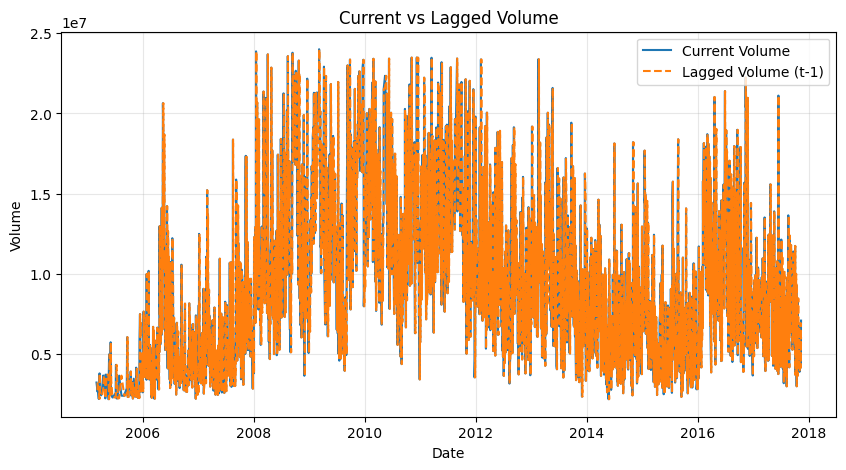

In [8]:
# Create a lagged version of the Volume column (lag)
categorized_df['Volume_lag1'] = categorized_df['Volume'].shift(1)

# Calculate the correlation between the current and lagged Volume
lagged_corr = categorized_df[['Volume', 'Volume_lag1']].corr()
print("Lagged Correlation:")
print(lagged_corr)

# Plot a comparison chart
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Current Volume')
plt.plot(categorized_df['Date'], categorized_df['Volume_lag1'], label='Lagged Volume (t-1)', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Current vs Lagged Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Cumulative Analysis

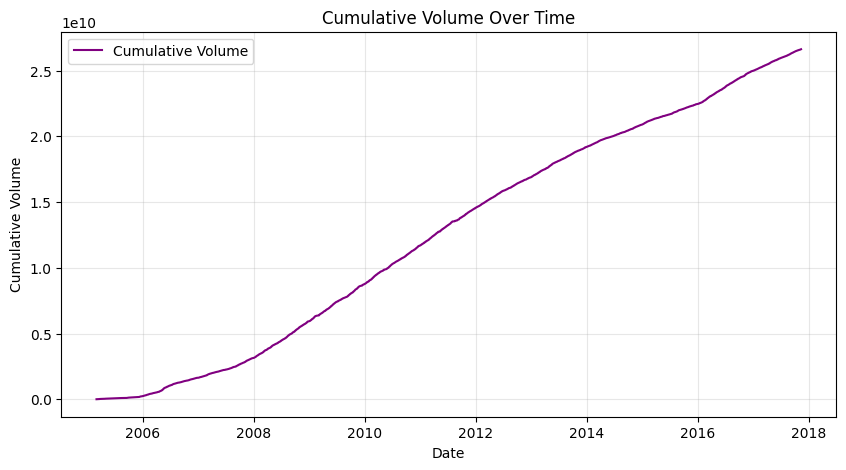

In [9]:
categorized_df['Cumulative_Volume'] = categorized_df['Volume'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Cumulative_Volume'], color='purple', label='Cumulative Volume')
plt.xlabel("Date")
plt.ylabel("Cumulative Volume")
plt.title("Cumulative Volume Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Moving Average Analysis

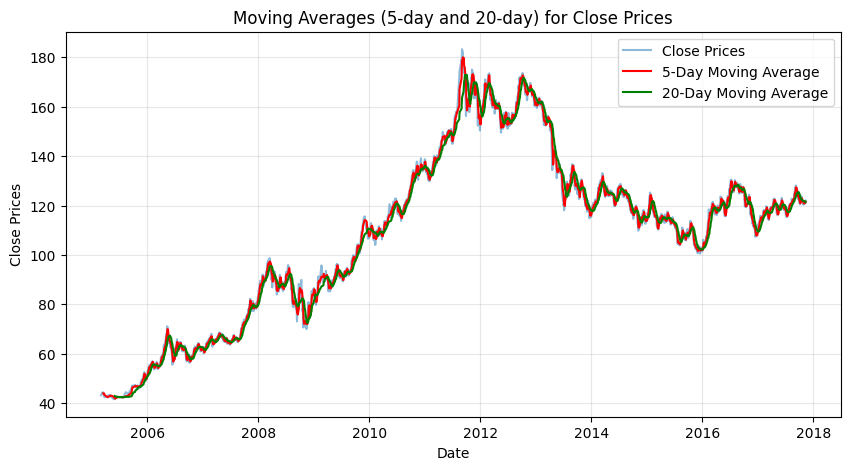

In [10]:
categorized_df['MA_5'] = categorized_df['Close'].rolling(window=5).mean()
categorized_df['MA_20'] = categorized_df['Close'].rolling(window=20).mean()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close Prices', alpha=0.5)
plt.plot(categorized_df['Date'], categorized_df['MA_5'], label='5-Day Moving Average', color='red')
plt.plot(categorized_df['Date'], categorized_df['MA_20'], label='20-Day Moving Average', color='green')
plt.xlabel("Date")
plt.ylabel("Close Prices")
plt.title("Moving Averages (5-day and 20-day) for Close Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Change point detection

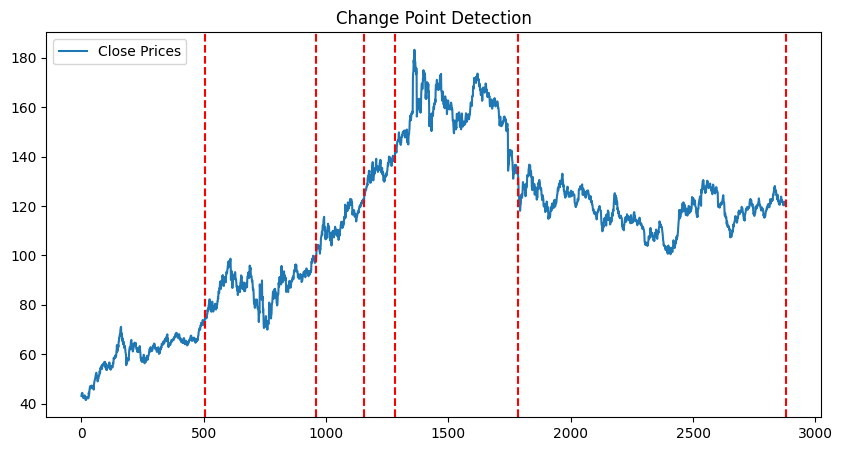

In [11]:
signal = categorized_df['Close'].values
algo = Binseg(model="l2").fit(signal)
change_points = algo.predict(n_bkps=5)

plt.figure(figsize=(10, 5))
plt.plot(signal, label="Close Prices")
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--')
plt.title("Change Point Detection")
plt.legend()
plt.show()

#### Volatility and Returns Analysis

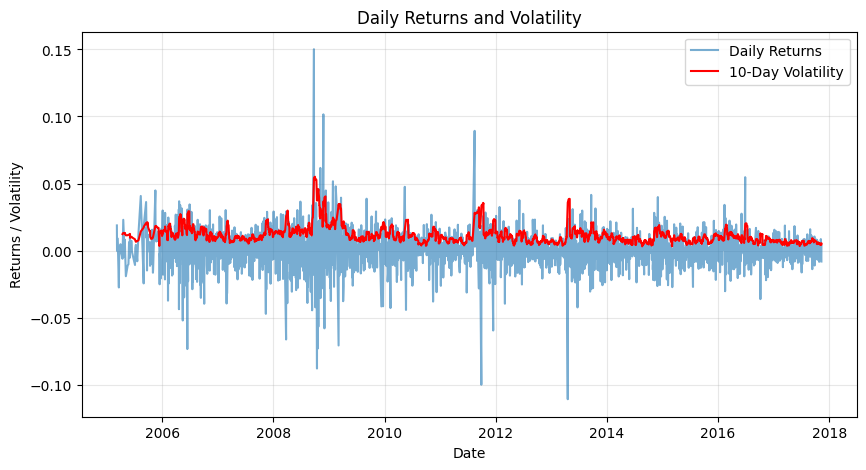

In [12]:
# Calculate daily returns
categorized_df['Daily_Return'] = categorized_df['Close'].pct_change()  # Percentage change for daily returns

# Calculate volatility
volatility = categorized_df['Daily_Return'].rolling(window=10).std()

# Plot daily returns and volatility
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Daily_Return'], label='Daily Returns', alpha=0.6)
plt.plot(categorized_df['Date'], volatility, label='10-Day Volatility', color='red')
plt.xlabel("Date")
plt.ylabel("Returns / Volatility")
plt.title("Daily Returns and Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Autocorrelation Analysis

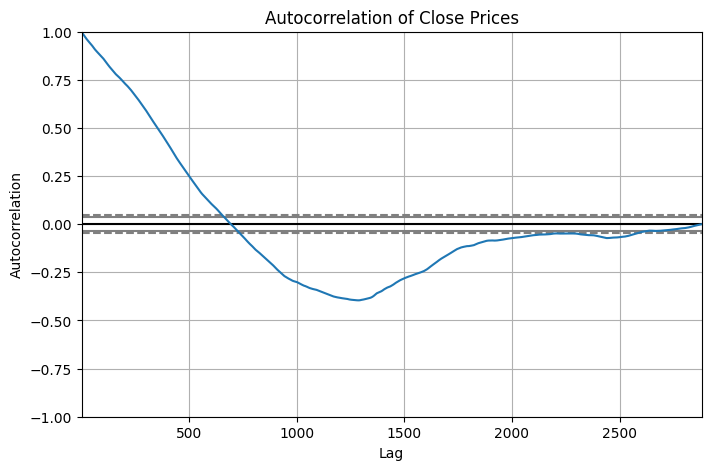

In [13]:
plt.figure(figsize=(8, 5))
autocorrelation_plot(categorized_df['Close'])
plt.title("Autocorrelation of Close Prices")
plt.show()